## 1. Importing necessary libraries

In [191]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics.pairwise import cosine_similarity
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

from sklearn.metrics import (accuracy_score,precision_score, recall_score, f1_score, confusion_matrix)

import matplotlib.pyplot as plt

##  2. Dataset Overview

In [119]:
df = pd.read_csv('german_credit_data.csv')
print(df.shape)
df.head()

(1000, 21)


,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


## 3.  Data Cleaning

In [121]:
df = df.drop_duplicates()

df.isna().sum() # print missing values

df  =  df.dropna(subset=['target', 'status_and_sex', 'age'])

df['Gender'] = df['status_and_sex'].apply(    # Extract Gender for fairness analysis
    lambda x: 'Female' if 'female' in str(x).lower() else 'Male'
)

df['target_binary'] = df['target'].map({      # converting target labels into binary values
    'bad': 0,
    'good': 1
})

print('After cleaning:',df.shape)
df[['status_and_sex','Gender','age','target','target_binary']].head()

After cleaning: (1000, 23)


,status_and_sex,Gender,age,target,target_binary
0,male : single,Male,67,good,1
1,female : divorced/separated/married,Female,22,bad,0
2,male : single,Male,49,good,1
3,male : single,Male,45,good,1
4,male : single,Male,53,bad,0


## 4.Exploratory Data Analysis

#### Target Distribution

target_binary
1    0.7
0    0.3
Name: proportion, dtype: float64


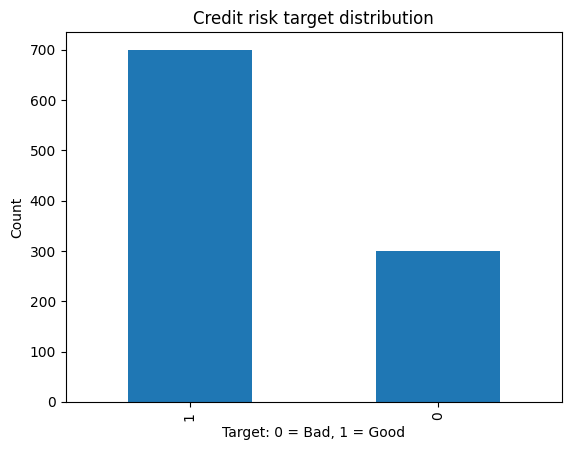

In [123]:
# checks whether the target variable is balanced or not
print(df["target_binary"].value_counts(normalize=True))

df["target_binary"].value_counts().plot(kind="bar")
plt.title("Credit risk target distribution")
plt.xlabel("Target: 0 = Bad, 1 = Good")
plt.ylabel("Count")
plt.show()

#### Gender Distribution

Gender distribution:
Gender
Male      0.69
Female    0.31
Name: proportion, dtype: float64


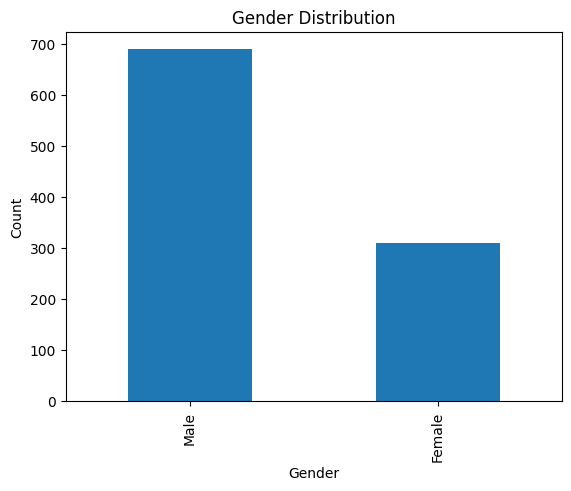

In [125]:
# prints Gender distribution because it is the protected attribute
print("Gender distribution:")
print(df["Gender"].value_counts(normalize=True))

df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

#### Good Credit Score by Gender

   Gender  Good credit score
0  Female           0.648387
1    Male           0.723188


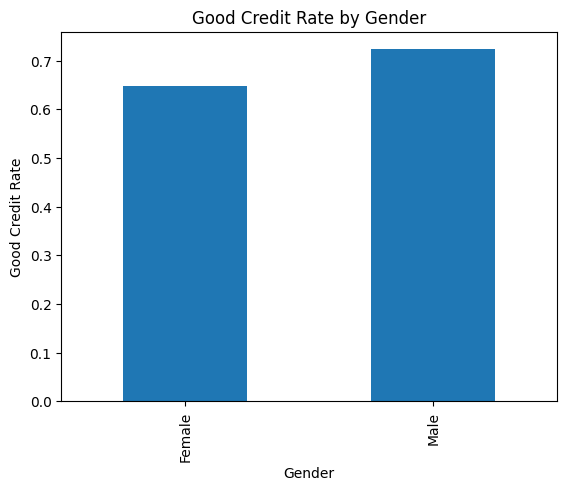

In [127]:
# check  whether males and females have different good credit scores
gender_good_score = df.groupby("Gender")["target_binary"].mean().reset_index()
gender_good_score.columns = ["Gender", "Good credit score"]

print(gender_good_score)

gender_good_score.plot(x="Gender", y="Good credit score", kind="bar", legend=False)
plt.title("Good Credit Rate by Gender")
plt.ylabel('Good Credit Rate')
plt.show()

#### Age group analysis

Age group distribution (%)
age_group
older    62.9
young    37.1
Name: proportion, dtype: float64


,Age group,Good credit rate
0,older,0.740859
1,young,0.630728


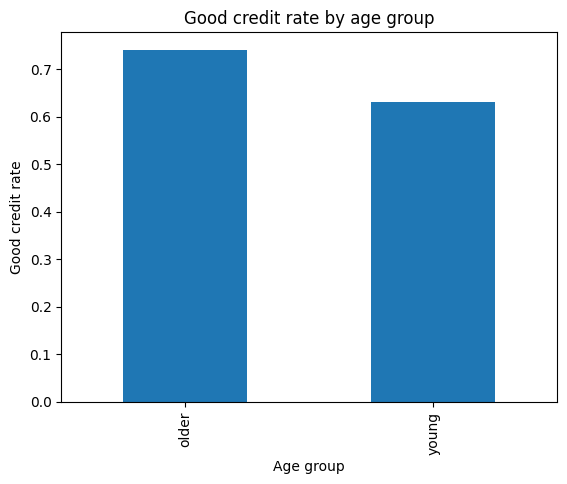

In [129]:
# creating an age group, where young applicants are below 30 and older are 30 or above
df['age_group'] = df['age'].apply(lambda x:'young'if x<30 else 'older')

print('Age group distribution (%)')
print((df['age_group'].value_counts(normalize = True) * 100).round(2))

# checks good credit by age
age_good_credit  = df.groupby('age_group')['target_binary'].mean().reset_index()
age_good_credit.columns = ['Age group','Good credit rate']

display(age_good_credit)

age_good_credit.plot(x='Age group',y='Good credit rate',kind='bar',legend=False)
plt.title('Good credit rate by age group')
plt.ylabel('Good credit rate')
plt.show()

## 5. Feature Engineering

In [131]:
target = 'target_binary'
protected_attribute = 'Gender'

drop_columns = [
    'target',
    'target_binary',
    'Gender',
    'status_and_sex',
    'age_group'  
]

x =  df.drop(columns =  [col for col in drop_columns if col in df.columns])
y = df[target]

#  creates 'gender' for fairness evaluation
gender = df[protected_attribute]

print('Features used for  prediction:')
print(x.columns.tolist())

Features used for  prediction:
['status_account', 'month_duration', 'credit_history', 'purpose', 'credit_amount', 'status_savings', 'years_employment', 'payment_to_income_ratio', 'secondary_obligor', 'residence_since', 'collateral', 'age', 'other_installment_plans', 'housing', 'n_credits', 'job', 'n_guarantors', 'telephone', 'is_foreign_worker']


## 6. Train-Test Split

In [133]:
x_train, x_test, y_train, y_test,  gender_train, gender_test = train_test_split(
    x,
    y,
    gender,
    test_size = 0.2,
    random_state = 42,
    stratify=y
)
print('Training shape:', x_train.shape)
print('Testing shape:', x_test.shape)  

Training shape: (800, 19)
Testing shape: (200, 19)


## 7. Data Preprocessing

In [135]:
numeric_features = x.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = x.select_dtypes(include=['object']).columns.tolist()

print('Numeric features:',numeric_features)
print('Categorical features:',categorical_features)

#scaling numeric columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

Numeric features: ['month_duration', 'credit_amount', 'payment_to_income_ratio', 'residence_since', 'age', 'n_credits', 'n_guarantors']
Categorical features: ['status_account', 'credit_history', 'purpose', 'status_savings', 'years_employment', 'secondary_obligor', 'collateral', 'other_installment_plans', 'housing', 'job', 'telephone', 'is_foreign_worker']


####  Fairness metric functions

In [137]:
# positive prediction rate 
def positive_prediction(y_pred, group_values, group_name):
    mask = group_values  == group_name

    if mask.sum() ==  0:
        return np.nan

    return np.mean(y_pred[mask] == 1)

# false positive rate and false negative rate
def calculate_fpr_fnr(y_true_group, y_pred_group):
    tn, fp, fn, tp = confusion_matrix(
        y_true_group,
        y_pred_group,
        labels = [0,1]
    ).ravel()

    fpr = fn / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    return fpr, fnr

# fairness metrics for male and female group
def fairness_metrics(
    y_true,
    y_pred,
    protected_values,
    privileged_group = 'Male',
    unprivileged_group ='Female'
):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    protected_values = pd.Series(protected_values).reset_index(drop=True)

    privileged_mask = protected_values ==  privileged_group
    unprivileged_mask = protected_values == unprivileged_group

    privileged_rate = positive_prediction(
        y_pred,
        protected_values,
        privileged_group
    )

    unprivileged_rate = positive_prediction(
        y_pred,
        protected_values,
        unprivileged_group
    )
    
    disparate_impact = (
        unprivileged_rate / privileged_rate
        if privileged_rate > 0 else np.nan
    )  

    disparate_treatment = abs(privileged_rate - unprivileged_rate)

    # FPR and FNR differences compare model error rates
    fpr_priv, fnr_priv = calculate_fpr_fnr(
        y_true[privileged_mask],
        y_pred[privileged_mask]
    )
    
    fpr_unpriv, fnr_unpriv = calculate_fpr_fnr(
        y_true[unprivileged_mask],
        y_pred[unprivileged_mask]
    )

    return{
        "Male Positive Prediction Rate": privileged_rate,
        "Female Positive Prediction Rate": unprivileged_rate,
        "Disparate Impact": disparate_impact,
        "Disparate Treatment": disparate_treatment,
        "FPR Difference": abs(fpr_unpriv - fpr_priv),
        "FNR Difference": abs(fnr_unpriv - fnr_priv)
    }

# count how many fairness metrics indicate unfairness
def unfair_decision_count(metrics):
    count = 0
    
    if metrics["Disparate Impact"] < 0.8 or metrics["Disparate Impact"] > 1.25:
        count += 1

    if metrics["Disparate Treatment"] > 0.10:
        count += 1

    if metrics["FPR Difference"] > 0.10:
        count += 1

    if metrics["FNR Difference"] > 0.10:
        count += 1

    return count
print("Fairness functions loaded successfully")

Fairness functions loaded successfully


#### Defining three models for comparison

In [139]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )
}

## 8. Model Training

In [141]:
# list to store model results
performance_results = []
fairness_results = []
trained_pipelines = {}

for model_name, model in models.items():
    print("Training:", model_name)

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )
    pipeline.fit(x_train, y_train)

    y_pred = pipeline.predict(x_test)

    trained_pipelines[model_name] = pipeline

    # Calculate performance metrics
    performance = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    }
    # Calculate fairness metrics
    fairness = fairness_metrics(
        y_true=y_test,
        y_pred=y_pred,
        protected_values=gender_test
    )

    fairness["Model"] = model_name
    fairness["Number of Unfair Results"] = unfair_decision_count(fairness)

    performance_results.append(performance)
    fairness_results.append(fairness)   

# converting results into dataframes
performance_df = pd.DataFrame(performance_results)
fairness_df = pd.DataFrame(fairness_results)

display(performance_df)
display(fairness_df)

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.700,0.781690,0.792857,0.787234
1,Decision Tree,0.685,0.725146,0.885714,0.797428
2,Random Forest,0.735,0.732620,0.978571,0.837920


,Male Positive Prediction Rate,Female Positive Prediction Rate,Disparate Impact,Disparate Treatment,FPR Difference,FNR Difference,Model,Number of Unfair Results
0,0.721429,0.683333,0.947195,0.038095,0.025,0.060,Logistic Regression,0
1,0.885714,0.783333,0.884409,0.102381,0.200,0.120,Decision Tree,3
2,0.928571,0.950000,1.023077,0.021429,0.000,0.005,Random Forest,0


## 9. Confusion Matrix

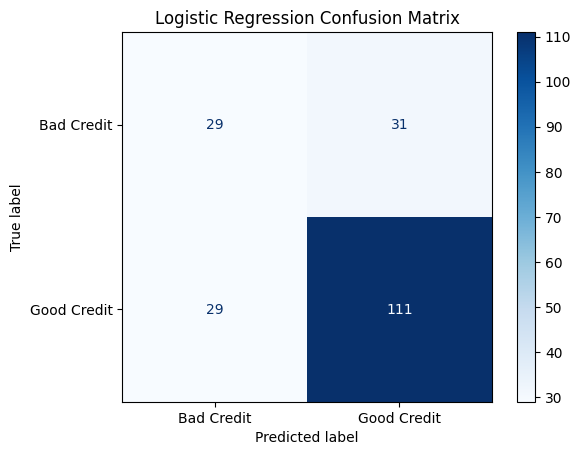

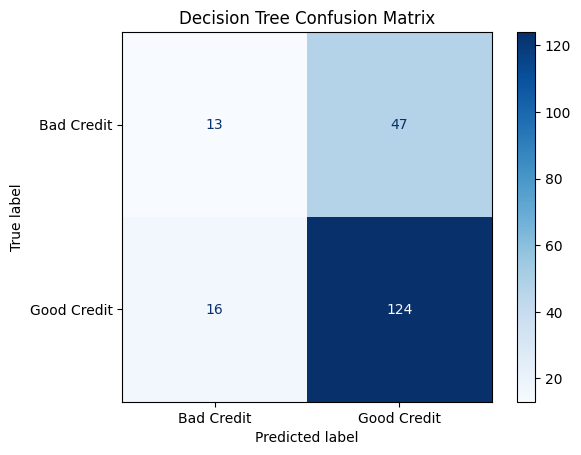

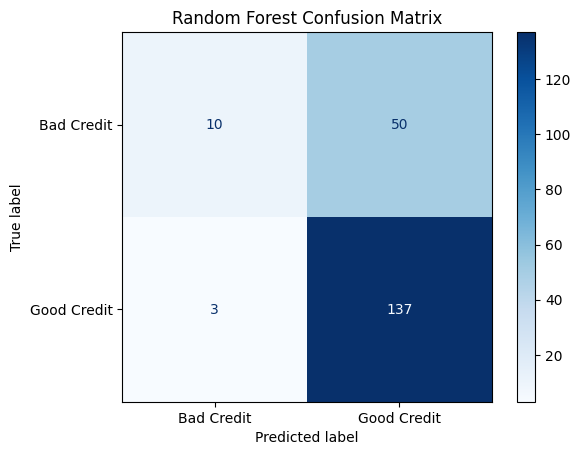

In [186]:
#  Error analysis
for model_name, pipeline in trained_pipelines.items():

    y_pred = pipeline.predict(x_test)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(Z
        confusion_matrix=cm,
        display_labels=["Bad Credit", "Good Credit"]
    )

    disp.plot(cmap="Blues")

    plt.title(f"{model_name} Confusion Matrix")

    plt.show()

## 10. Cosine Similarity

In [193]:
similarity_features = [
    'month_duration',
    'credit_amount',
    'payment_to_income_ratio',
    'age',
    'n_credits'
]

sample = df[similarity_features].head(5)

similarity_matrix = cosine_similarity(sample)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=sample.index,
    columns=sample.index
)

print("Cosine Similarity of sample spplicants")

display(similarity_df.round(3))

Cosine Similarity of sample spplicants


,0,1,2,3,4
0,1.000,0.999,0.999,0.999,0.999
1,0.999,1.000,1.000,1.000,1.000
2,0.999,1.000,1.000,1.000,1.000
3,0.999,1.000,1.000,1.000,1.000
4,0.999,1.000,1.000,1.000,1.000


## 11.  Association Rules

In [196]:
association_df = df[
    [
        'housing',
        'job',
        'is_foreign_worker',
        'target'
    ]
]

association_df = association_df.astype(str)

association_encoded = pd.get_dummies(
    association_df
)

frequent_items = apriori(
    association_encoded,
    min_support=0.1,
    use_colnames=True
)

rules = association_rules(
    frequent_items,
    metric='lift',
    min_threshold=1
)

display(
    rules[
        [
            'antecedents',
            'consequents',
            'support',
            'confidence',
            'lift'
        ]
    ]
    .sort_values(
        by='lift',
        ascending=False
    )
    .head(10)
)

,antecedents,consequents,support,confidence,lift
72,"(target_good, is_foreign_worker_yes, job_unski...",(housing_own),0.106,0.815385,1.143597
83,(housing_own),"(target_good, is_foreign_worker_yes, job_unski...",0.106,0.148668,1.143597
36,"(target_good, job_unskilled - resident)",(housing_own),0.116,0.805556,1.129811
41,(housing_own),"(target_good, job_unskilled - resident)",0.116,0.162693,1.129811
37,"(target_good, housing_own)",(job_unskilled - resident),0.116,0.220114,1.100569
40,(job_unskilled - resident),"(target_good, housing_own)",0.116,0.580000,1.100569
66,"(target_good, is_foreign_worker_yes)","(housing_own, job_skilled employee/ official)",0.329,0.493253,1.091269
65,"(housing_own, job_skilled employee/ official)","(target_good, is_foreign_worker_yes)",0.329,0.727876,1.091269
35,(housing_own),"(is_foreign_worker_yes, job_unskilled - resident)",0.144,0.201964,1.085825
32,"(is_foreign_worker_yes, job_unskilled - resident)",(housing_own),0.144,0.774194,1.085825


## 12.Model Selection for Mitigation

In [145]:
best_model = 'Decision Tree'

best_pipeline = trained_pipelines[best_model]

print("Selected model for mitigation:", best_model)

Selected model for mitigation: Decision Tree


##  13.  Bias Mitigation

#### Manual Reweighing  Function

In [147]:
def calculate_reweighing_weights(y_values, protected_values):
    data = pd.DataFrame({
        "label": y_values.values,
        "group": protected_values.values
    })

    total = len(data)
    weights = []

    for _, row in data.iterrows():
        y_val = row["label"]
        group_val = row["group"]

        p_y = len(data[data["label"] == y_val]) / total
        p_group = len(data[data["group"] == group_val]) / total

        p_y_group = len(
            data[
                (data["label"] == y_val) &
                (data["group"] == group_val)
            ]
        ) / total

        weight = (p_y * p_group) / p_y_group if p_y_group > 0 else 1
        weights.append(weight)

    return np.array(weights)


# Calculate weights using training data 
sample_weights = calculate_reweighing_weights(y_train, gender_train)

print("Sample weight :")
print(pd.Series(sample_weights).describe())

Sample weight :
count    800.000000
mean       1.000000
std        0.080742
min        0.842697
25%        0.964912
50%        0.964912
75%        1.086957
max        1.092715
dtype: float64


#### Retraining Decision Tree with Reweighing

In [154]:
#  creating a new Decision Treemodel for mitigation
mitigated_new_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)


mitigated_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", mitigated_new_model)
    ]
)
#  training
mitigated_pipeline.fit(
    x_train,
    y_train,
    classifier__sample_weight=sample_weights
)


y_pred_before = best_pipeline.predict(x_test)
y_pred_after = mitigated_pipeline.predict(x_test)

#### Comparison of model performance before and after mitigation

In [157]:
performance_before_after = pd.DataFrame([
    {
        "Stage": "Before Mitigation",
        "Accuracy": accuracy_score(y_test, y_pred_before),
        "Precision": precision_score(y_test, y_pred_before, zero_division=0),
        "Recall": recall_score(y_test, y_pred_before, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_before, zero_division=0)
    },
    {
        "Stage": "After Mitigation",
        "Accuracy": accuracy_score(y_test, y_pred_after),
        "Precision": precision_score(y_test, y_pred_after, zero_division=0),
        "Recall": recall_score(y_test, y_pred_after, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_after, zero_division=0)
    }
])

display(performance_before_after)

,Stage,Accuracy,Precision,Recall,F1 Score
0,Before Mitigation,0.685,0.725146,0.885714,0.797428
1,After Mitigation,0.730,0.790541,0.835714,0.812500


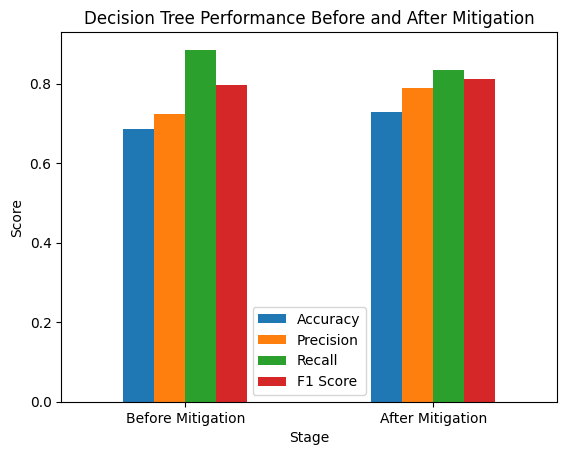

In [170]:
performance_before_after.set_index("Stage").plot(kind="bar")

plt.title("Decision Tree Performance Before and After Mitigation")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

#### Comparison of fairness metrics before and after mitigation

In [162]:
#  fairness metrics before mitigation
fairness_before = fairness_metrics(
    y_true=y_test,
    y_pred=y_pred_before,
    protected_values=gender_test
)

# fairness metrics after mitigation
fairness_after = fairness_metrics(
    y_true=y_test,
    y_pred=y_pred_after,
    protected_values=gender_test
)

fairness_before["Stage"] = "Before Mitigation"
fairness_after["Stage"] = "After Mitigation"

fairness_before["Number of Unfair Results"] = unfair_decision_count(fairness_before)
fairness_after["Number of Unfair Results"] = unfair_decision_count(fairness_after)

fairness_before_after = pd.DataFrame([
    fairness_before,
    fairness_after
])

cols = ["Stage"] + [
    col for col in fairness_before_after.columns
    if col != "Stage"
]

fairness_before_after = fairness_before_after[cols]

display(fairness_before_after)

,Stage,Male Positive Prediction Rate,Female Positive Prediction Rate,Disparate Impact,Disparate Treatment,FPR Difference,FNR Difference,Number of Unfair Results
0,Before Mitigation,0.885714,0.783333,0.884409,0.102381,0.200,0.12,3
1,After Mitigation,0.757143,0.700000,0.924528,0.057143,0.175,0.12,2


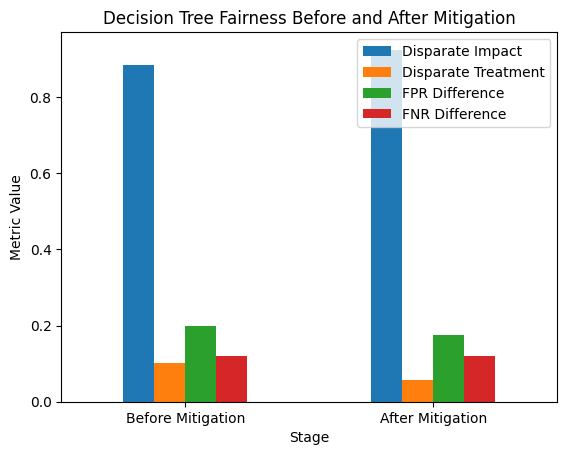

In [172]:
fairness_before_after.set_index("Stage")[
    [
        "Disparate Impact",
        "Disparate Treatment",
        "FPR Difference",
        "FNR Difference"
    ]
].plot(kind="bar")

plt.title("Decision Tree Fairness Before and After Mitigation")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.show()

## 14.  Results

In [176]:
print("Final selected model for mitigation:", best_model)

print("Unfair results before mitigation:",
      fairness_before["Number of Unfair Results"])

print("Unfair results after mitigation:",
      fairness_after["Number of Unfair Results"])

print("\nBaseline model comparison:")
display(combined_results)

print("\nDecision Tree performance before and after mitigation:")
display(performance_before_after)

print("\nDecision Tree fairness before and after mitigation:")
display(fairness_before_after)

Final selected model for mitigation: Decision Tree
Unfair results before mitigation: 3
Unfair results after mitigation: 2

Baseline model comparison:


,Model,Accuracy,Precision,Recall,F1 Score,Male Positive Prediction Rate,Female Positive Prediction Rate,Disparate Impact,Disparate Treatment,FPR Difference,FNR Difference,Number of Unfair Results
0,Logistic Regression,0.700,0.781690,0.792857,0.787234,0.721429,0.683333,0.947195,0.038095,0.025,0.060,0
1,Decision Tree,0.685,0.725146,0.885714,0.797428,0.885714,0.783333,0.884409,0.102381,0.200,0.120,3
2,Random Forest,0.735,0.732620,0.978571,0.837920,0.928571,0.950000,1.023077,0.021429,0.000,0.005,0



Decision Tree performance before and after mitigation:


,Stage,Accuracy,Precision,Recall,F1 Score
0,Before Mitigation,0.685,0.725146,0.885714,0.797428
1,After Mitigation,0.730,0.790541,0.835714,0.812500



Decision Tree fairness before and after mitigation:


,Stage,Male Positive Prediction Rate,Female Positive Prediction Rate,Disparate Impact,Disparate Treatment,FPR Difference,FNR Difference,Number of Unfair Results
0,Before Mitigation,0.885714,0.783333,0.884409,0.102381,0.200,0.12,3
1,After Mitigation,0.757143,0.700000,0.924528,0.057143,0.175,0.12,2
